# Milestone 2

In [263]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split , StratifiedKFold
from sklearn.preprocessing import LabelEncoder , StandardScaler,PowerTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [227]:
df= pd.read_csv("train_data.csv")
df.head()

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,vitamin_a_percent_rda,vitamin_c_percent_rda,vitamin_d_percent_rda,vitamin_e_percent_rda,vitamin_b12_percent_rda,folate_percent_rda,calcium_percent_rda,iron_percent_rda,symptoms_count,symptoms_list,disease_diagnosis
0,79,Male,24.8,Former,NaN,Active,Vegetarian,High,High,Mid,119.1,147.3,152.88,97.5,102.5,188.9,108.3,97.4,0,NaN,Healthy
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,Low,Low,85.7,57.5,32.76,82.7,62.6,51.0,42.6,102.5,1,bone_pain,Rickets_Osteomalacia
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,High,High,48.3,152.1,94.99,169.3,136.2,116.6,136.3,86.4,2,dry_skin;night_blindness,Healthy
3,69,Male,23.1,Never,Heavy,Moderate,Vegetarian,High,Low,Low,75.8,51.0,51.48,85.7,31.8,66.5,76.5,60.8,2,numbness_tingling;memory_problems,Anemia
4,63,Male,29.6,Never,NaN,Moderate,Vegetarian,Moderate,High,Low,93.3,111.5,62.90,155.6,72.6,124.9,69.4,71.9,0,NaN,Healthy


In [228]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      3500 non-null   int64  
 1   gender                   3500 non-null   object 
 2   bmi                      3500 non-null   float64
 3   smoking_status           3500 non-null   object 
 4   alcohol_consumption      2390 non-null   object 
 5   exercise_level           3500 non-null   object 
 6   diet_type                3500 non-null   object 
 7   sun_exposure             3500 non-null   object 
 8   income_level             3500 non-null   object 
 9   latitude_region          3500 non-null   object 
 10  vitamin_a_percent_rda    3500 non-null   float64
 11  vitamin_c_percent_rda    3500 non-null   float64
 12  vitamin_d_percent_rda    3500 non-null   float64
 13  vitamin_e_percent_rda    3500 non-null   float64
 14  vitamin_b12_percent_rda 

In [229]:
# count =df["disease_diagnosis"].value_counts()
# print(count)
# count =df["smoking_status"].value_counts()
# print(count)
# count =df["alcohol_consumption"].value_counts()
# print(count)
# count =df["exercise_level"].value_counts()
# print(count)
count =df["latitude_region"].value_counts()
print(count)


latitude_region
High    1187
Low     1175
Mid     1138
Name: count, dtype: int64


In [ ]:
# X = df.drop(columns=["disease_diagnosis"])
df = pd.get_dummies(df, columns=["gender"])
df.head()

,age,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,vitamin_a_percent_rda,vitamin_c_percent_rda,vitamin_d_percent_rda,vitamin_e_percent_rda,vitamin_b12_percent_rda,folate_percent_rda,calcium_percent_rda,iron_percent_rda,symptoms_count,symptoms_list,disease_diagnosis,gender_Female,gender_Male
0,79,24.8,Former,NaN,Active,Vegetarian,High,High,Mid,119.1,147.3,152.88,97.5,102.5,188.9,108.3,97.4,0,NaN,Healthy,False,True
1,77,39.9,Former,Moderate,Light,Omnivore,Low,Low,Low,85.7,57.5,32.76,82.7,62.6,51.0,42.6,102.5,1,bone_pain,Rickets_Osteomalacia,True,False
2,24,26.4,Former,Heavy,Moderate,Omnivore,Low,High,High,48.3,152.1,94.99,169.3,136.2,116.6,136.3,86.4,2,dry_skin;night_blindness,Healthy,False,True
3,69,23.1,Never,Heavy,Moderate,Vegetarian,High,Low,Low,75.8,51.0,51.48,85.7,31.8,66.5,76.5,60.8,2,numbness_tingling;memory_problems,Anemia,False,True
4,63,29.6,Never,NaN,Moderate,Vegetarian,Moderate,High,Low,93.3,111.5,62.90,155.6,72.6,124.9,69.4,71.9,0,NaN,Healthy,False,True


In [231]:
smoking_map = {'Never':0 , 'Former':1 , 'Current':2}
df["smoking_status"] = df["smoking_status"].map(smoking_map)

In [232]:
classes = df["disease_diagnosis"].unique()

       
df['alcohol_consumption'] = df.groupby('disease_diagnosis')['alcohol_consumption'] \
                      .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))    
df.info()                     

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      3500 non-null   int64  
 1   bmi                      3500 non-null   float64
 2   smoking_status           3500 non-null   int64  
 3   alcohol_consumption      3500 non-null   object 
 4   exercise_level           3500 non-null   object 
 5   diet_type                3500 non-null   object 
 6   sun_exposure             3500 non-null   object 
 7   income_level             3500 non-null   object 
 8   latitude_region          3500 non-null   object 
 9   vitamin_a_percent_rda    3500 non-null   float64
 10  vitamin_c_percent_rda    3500 non-null   float64
 11  vitamin_d_percent_rda    3500 non-null   float64
 12  vitamin_e_percent_rda    3500 non-null   float64
 13  vitamin_b12_percent_rda  3500 non-null   float64
 14  folate_percent_rda      

In [233]:
alc_map = {'Moderate':0 , 'Heavy':1 }
df["alcohol_consumption"] = df["alcohol_consumption"].map(alc_map)

In [234]:
# exercise_level
# Sedentary    903
# Light        884
# Active       866
# Moderate     847
alc_map = {'Sedentary':0 , 'Light':1 , 'Moderate':2 , 'Active':3 }
df["exercise_level"] = df["exercise_level"].map(alc_map)

In [235]:
# diet_type
# Vegan          887
# Pescatarian    876
# Omnivore       870
# Vegetarian     867
# diet_map = {'Vegan':0 , 'Pescatarian':1 , 'Omnivore':2 , 'Vegetarian':3 }
# df["diet_type"] = df["diet_type"].map(diet_map)
df = pd.get_dummies(df, columns=["diet_type"])


In [236]:
sun_exposurelll = {'Low':0 , 'Moderate':1 , 'High':2  }
df["sun_exposure"] = df["sun_exposure"].map(sun_exposurelll)

In [237]:
income = {'Low':0 , 'Middle':1 , 'High':2  }
df["income_level"] = df["income_level"].map(income)

In [238]:
lats = {'Low':0 , 'Mid':1 , 'High':2  }
df["latitude_region"] = df["latitude_region"].map(lats)

In [239]:
df.drop(columns=["symptoms_list"], inplace=True)

In [240]:
le = LabelEncoder()
df["disease_diagnosis"] = le.fit_transform(df["disease_diagnosis"])

In [241]:
df.head()

,age,bmi,smoking_status,alcohol_consumption,exercise_level,sun_exposure,income_level,latitude_region,vitamin_a_percent_rda,vitamin_c_percent_rda,vitamin_d_percent_rda,vitamin_e_percent_rda,vitamin_b12_percent_rda,folate_percent_rda,calcium_percent_rda,iron_percent_rda,symptoms_count,disease_diagnosis,gender_Female,gender_Male,diet_type_Omnivore,diet_type_Pescatarian,diet_type_Vegan,diet_type_Vegetarian
0,79,24.8,1,0,3,2,2,1,119.1,147.3,152.88,97.5,102.5,188.9,108.3,97.4,0,1,False,True,False,False,False,True
1,77,39.9,1,0,1,0,0,0,85.7,57.5,32.76,82.7,62.6,51.0,42.6,102.5,1,3,True,False,True,False,False,False
2,24,26.4,1,1,2,0,2,2,48.3,152.1,94.99,169.3,136.2,116.6,136.3,86.4,2,1,False,True,True,False,False,False
3,69,23.1,0,1,2,2,0,0,75.8,51.0,51.48,85.7,31.8,66.5,76.5,60.8,2,0,False,True,False,False,False,True
4,63,29.6,0,0,2,1,2,0,93.3,111.5,62.90,155.6,72.6,124.9,69.4,71.9,0,1,False,True,False,False,False,True


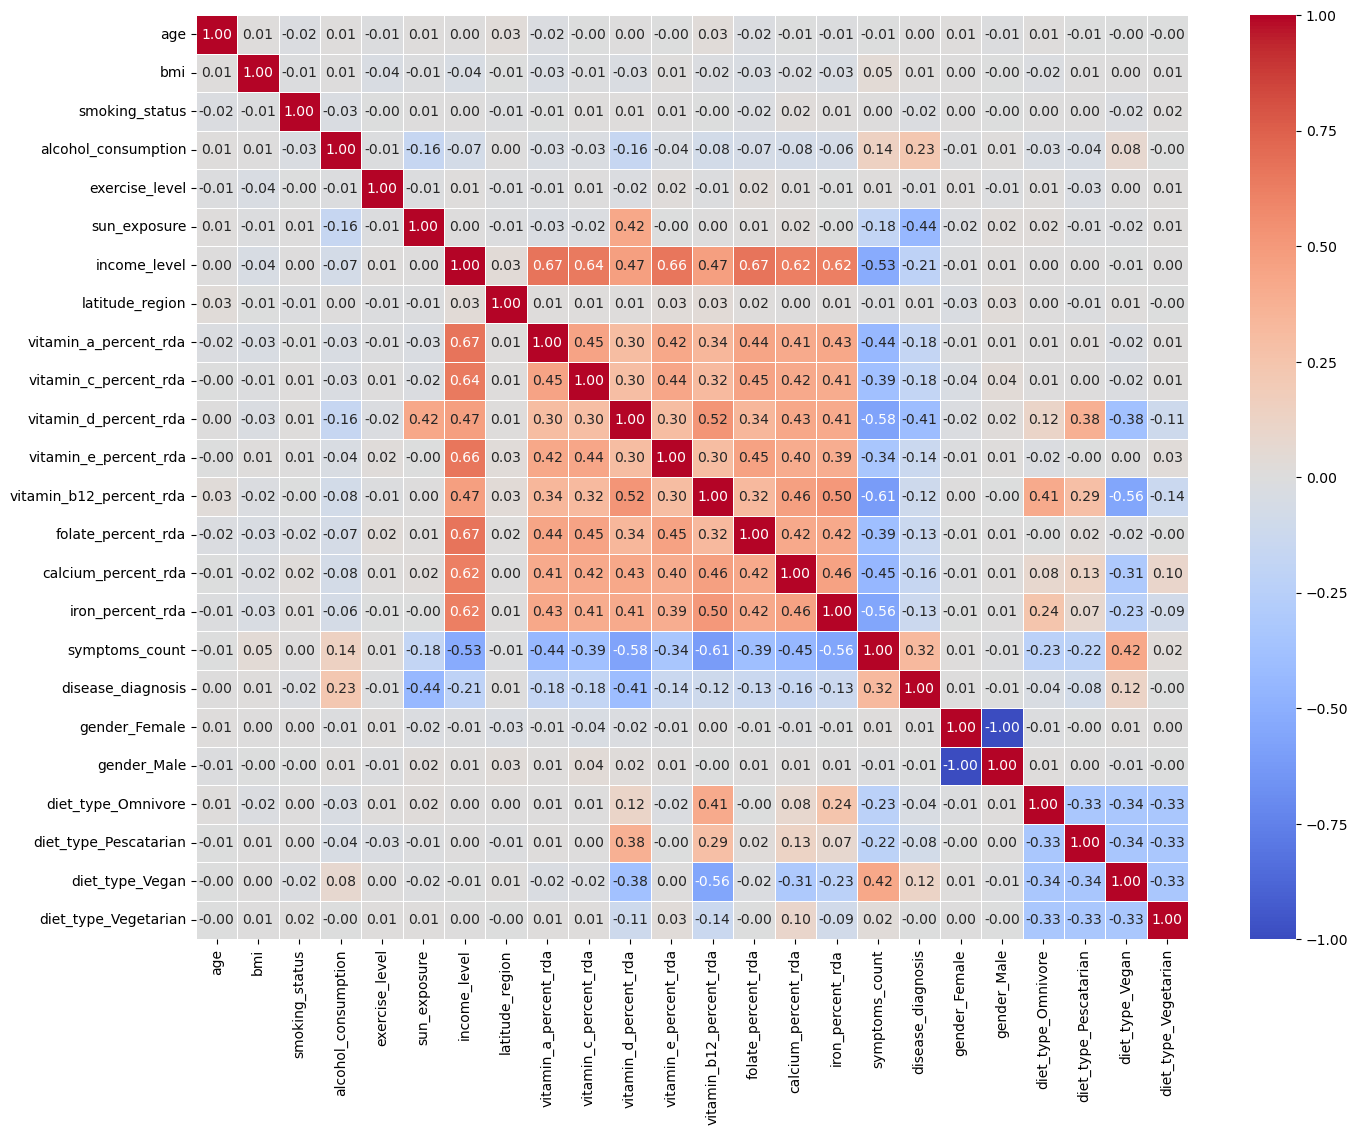

In [242]:
plt.figure(figsize=(16,12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5,fmt=".2f")
plt.show()

In [243]:

df.drop(columns=["gender_Male","gender_Female","age","bmi","smoking_status","exercise_level","latitude_region"], inplace=True)

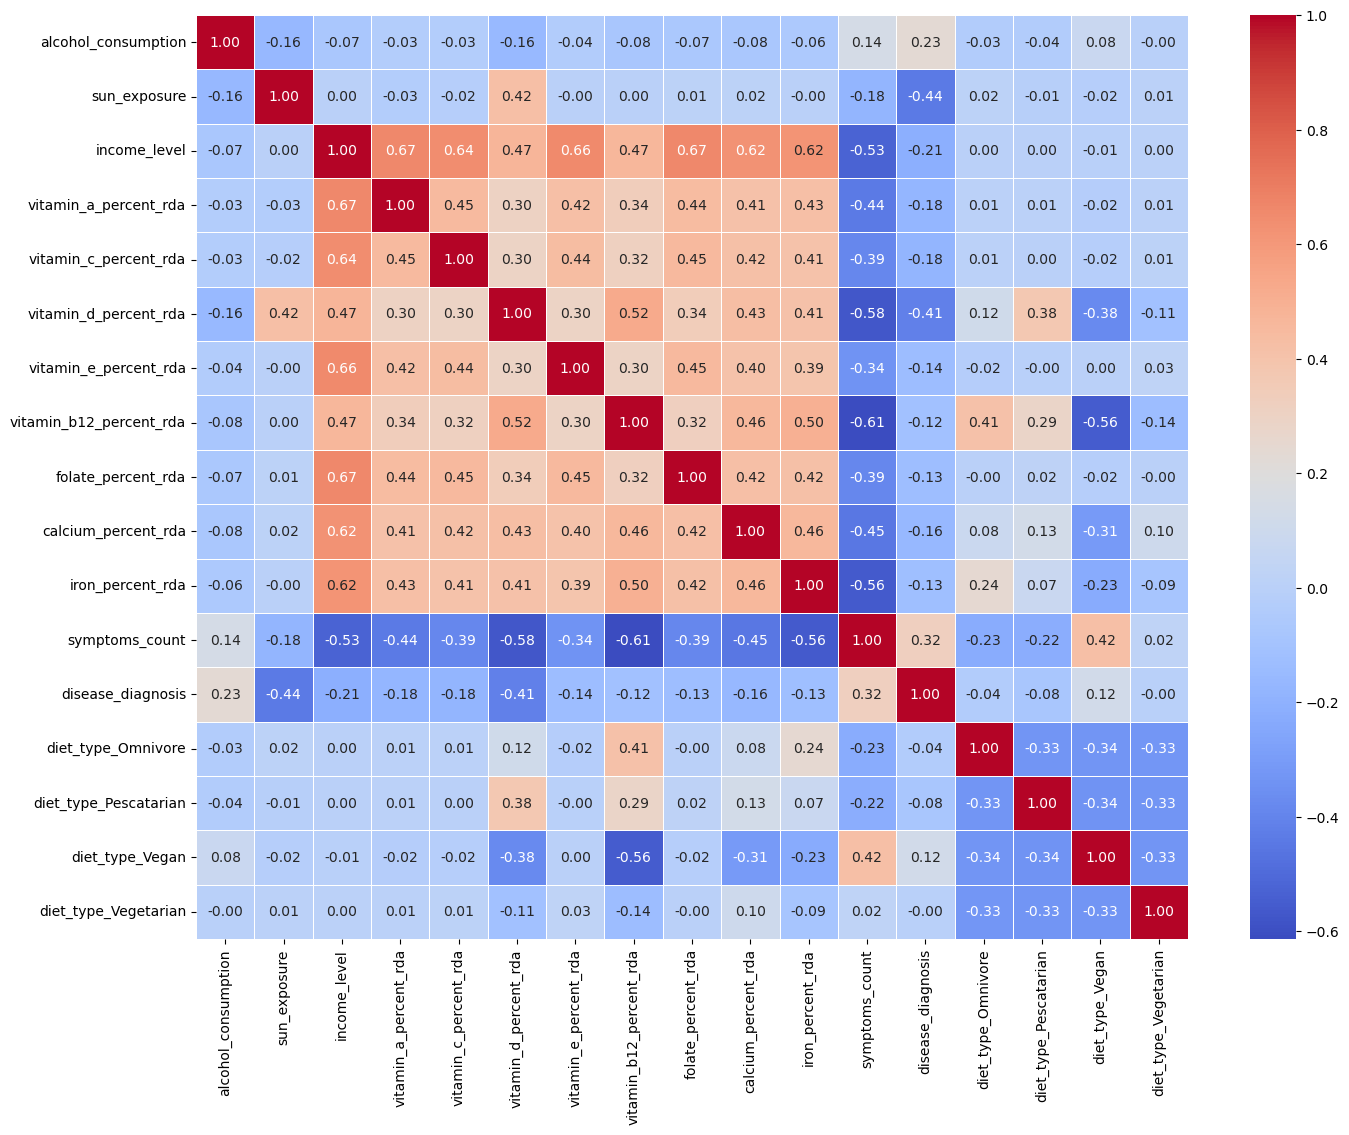

In [244]:
plt.figure(figsize=(16,12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5,fmt=".2f")
plt.show()

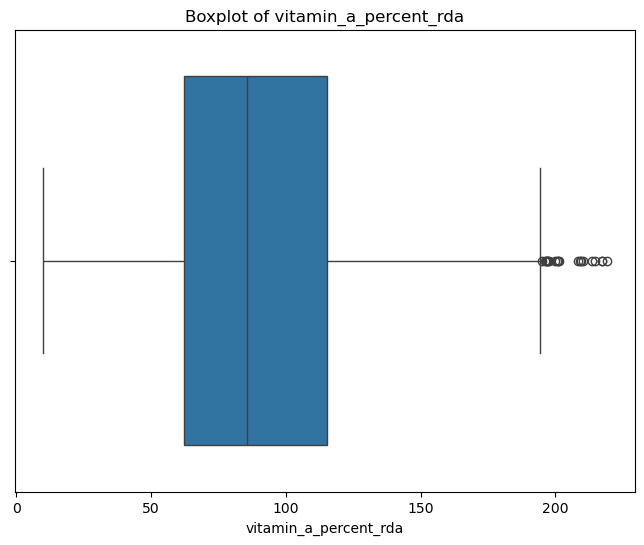

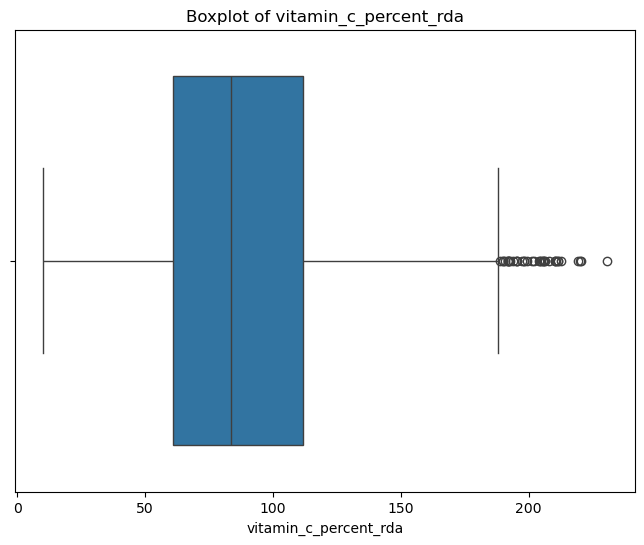

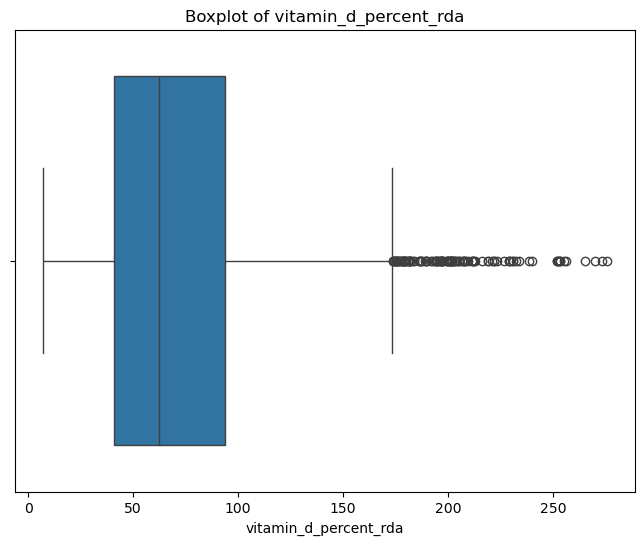

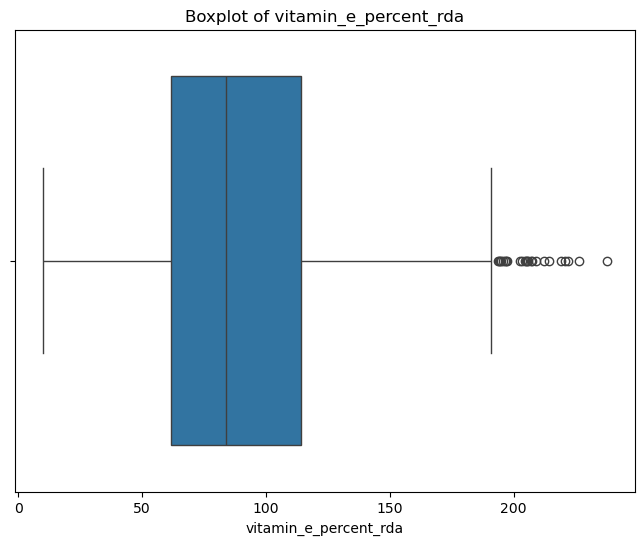

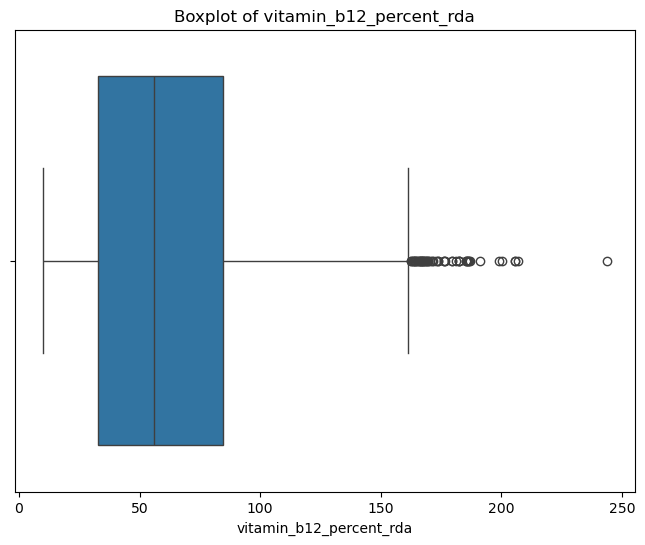

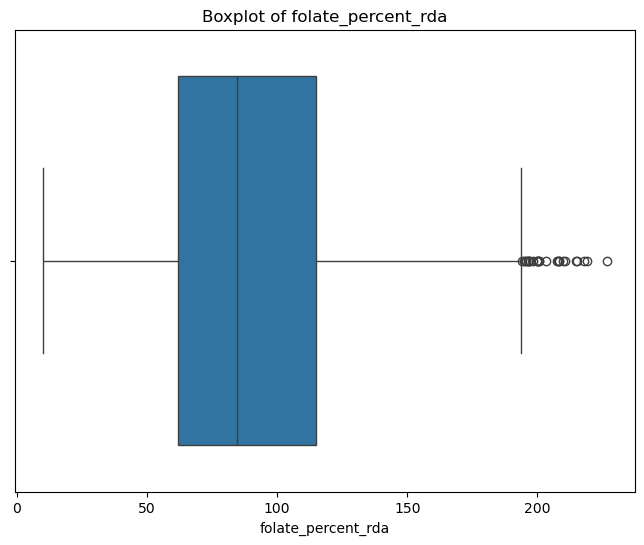

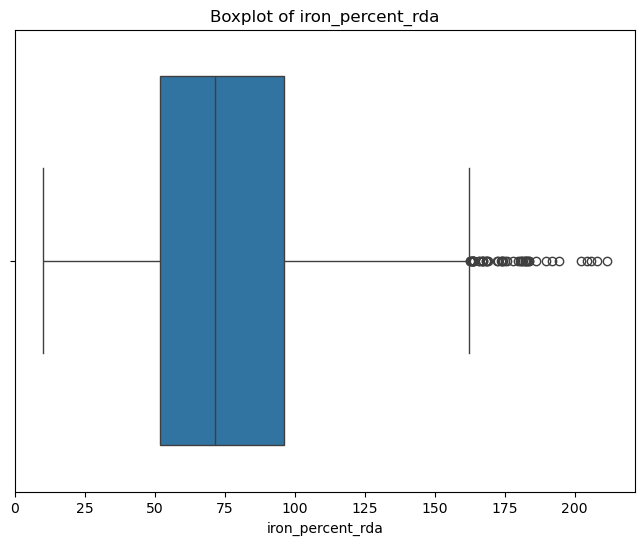

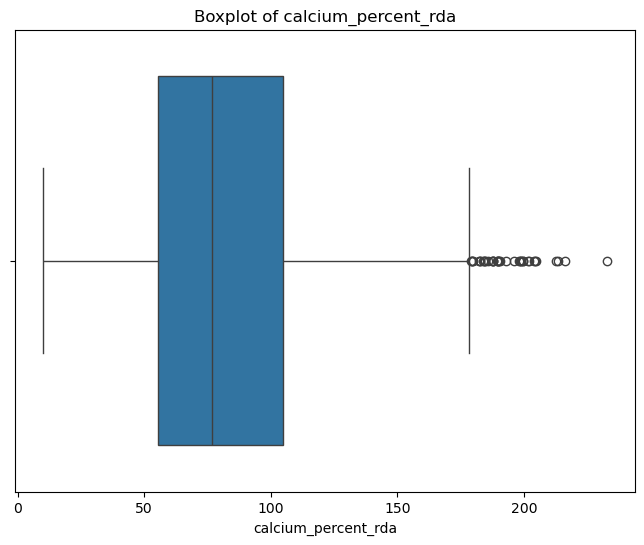

In [245]:
cols= ["vitamin_a_percent_rda","vitamin_c_percent_rda","vitamin_d_percent_rda","vitamin_e_percent_rda","vitamin_b12_percent_rda","folate_percent_rda","iron_percent_rda","calcium_percent_rda"]
for col in cols:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [246]:
outlier_dict ={}
for column in cols:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column]= df[column].clip(lower_bound, upper_bound)
    # outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    # outlier_dict[column] = outliers

In [247]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   alcohol_consumption      3500 non-null   int64  
 1   sun_exposure             3500 non-null   int64  
 2   income_level             3500 non-null   int64  
 3   vitamin_a_percent_rda    3500 non-null   float64
 4   vitamin_c_percent_rda    3500 non-null   float64
 5   vitamin_d_percent_rda    3500 non-null   float64
 6   vitamin_e_percent_rda    3500 non-null   float64
 7   vitamin_b12_percent_rda  3500 non-null   float64
 8   folate_percent_rda       3500 non-null   float64
 9   calcium_percent_rda      3500 non-null   float64
 10  iron_percent_rda         3500 non-null   float64
 11  symptoms_count           3500 non-null   int64  
 12  disease_diagnosis        3500 non-null   int64  
 13  diet_type_Omnivore       3500 non-null   bool   
 14  diet_type_Pescatarian   

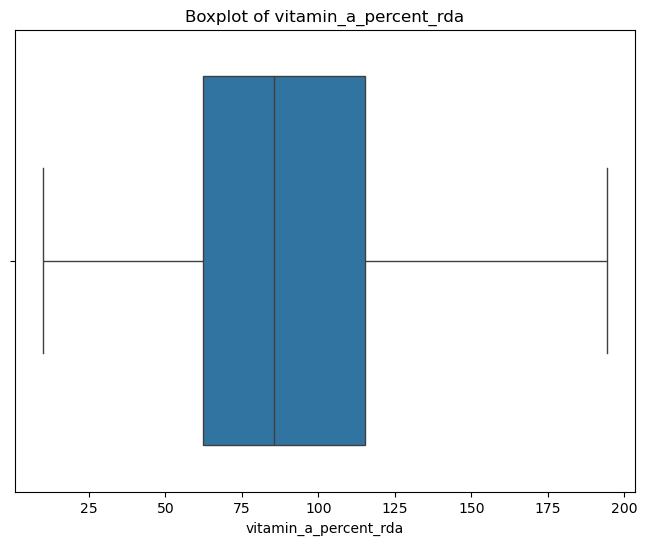

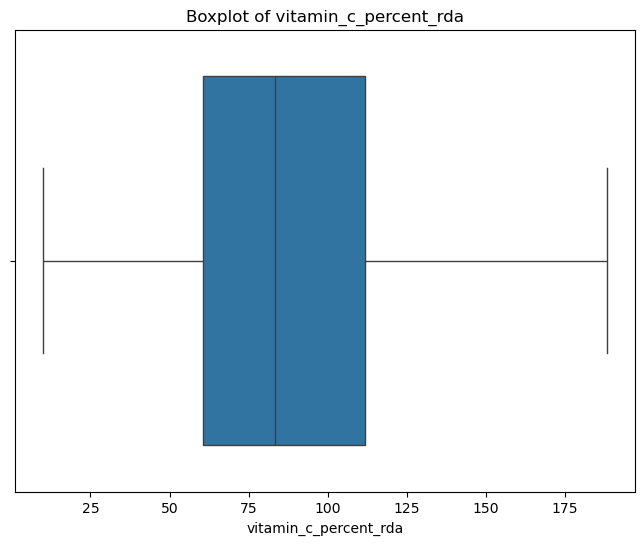

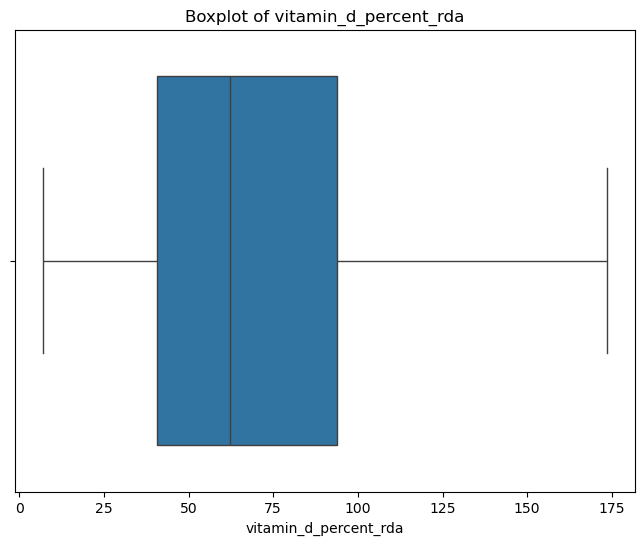

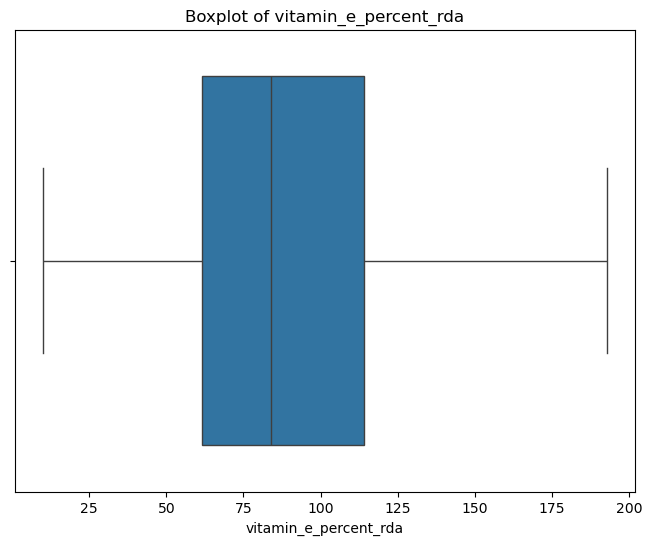

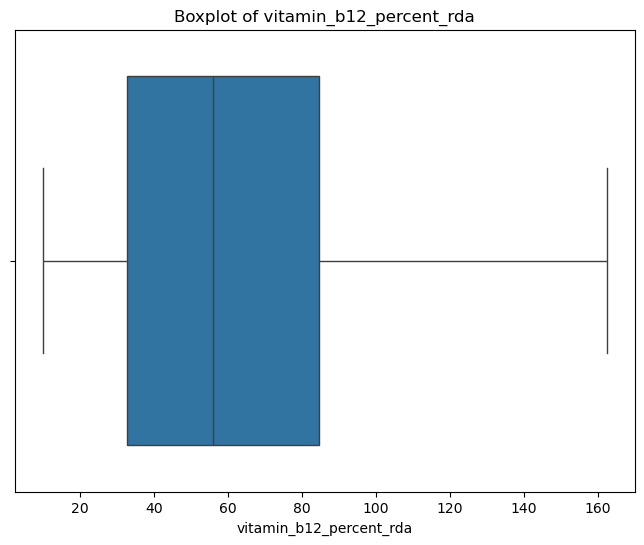

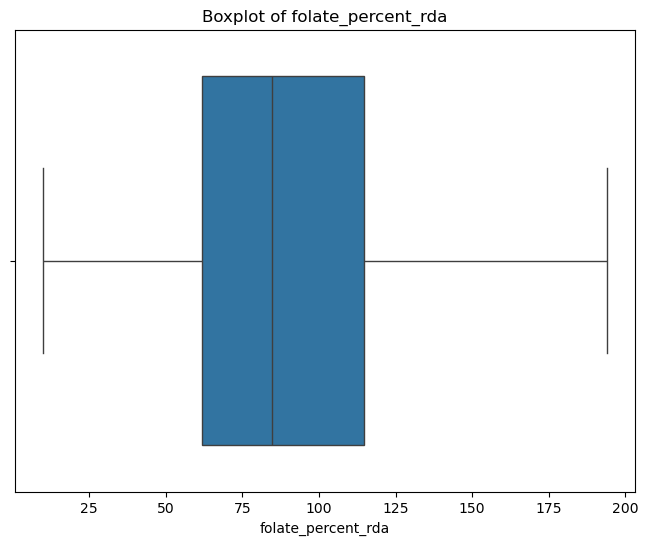

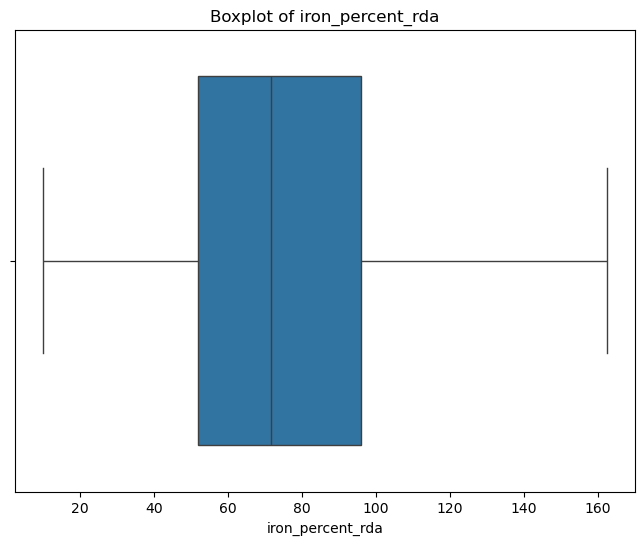

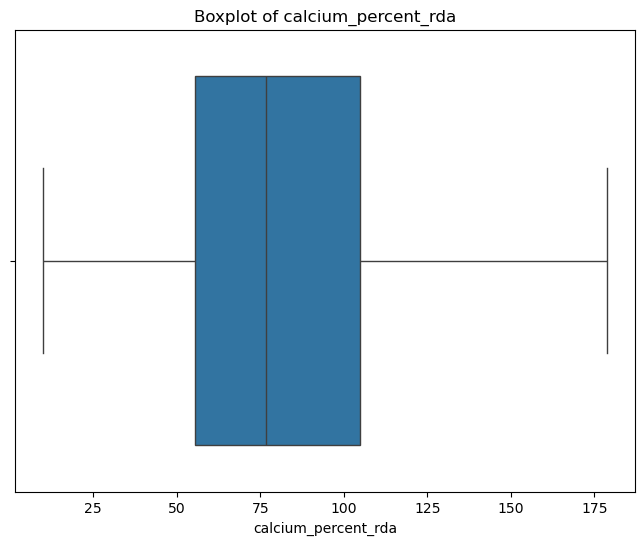

In [248]:
cols= ["vitamin_a_percent_rda","vitamin_c_percent_rda","vitamin_d_percent_rda","vitamin_e_percent_rda","vitamin_b12_percent_rda","folate_percent_rda","iron_percent_rda","calcium_percent_rda"]
for col in cols:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

array([[<Axes: title={'center': 'alcohol_consumption'}>,
        <Axes: title={'center': 'sun_exposure'}>,
        <Axes: title={'center': 'income_level'}>,
        <Axes: title={'center': 'vitamin_a_percent_rda'}>],
       [<Axes: title={'center': 'vitamin_c_percent_rda'}>,
        <Axes: title={'center': 'vitamin_d_percent_rda'}>,
        <Axes: title={'center': 'vitamin_e_percent_rda'}>,
        <Axes: title={'center': 'vitamin_b12_percent_rda'}>],
       [<Axes: title={'center': 'folate_percent_rda'}>,
        <Axes: title={'center': 'calcium_percent_rda'}>,
        <Axes: title={'center': 'iron_percent_rda'}>,
        <Axes: title={'center': 'symptoms_count'}>],
       [<Axes: title={'center': 'disease_diagnosis'}>, <Axes: >,
        <Axes: >, <Axes: >]], dtype=object)

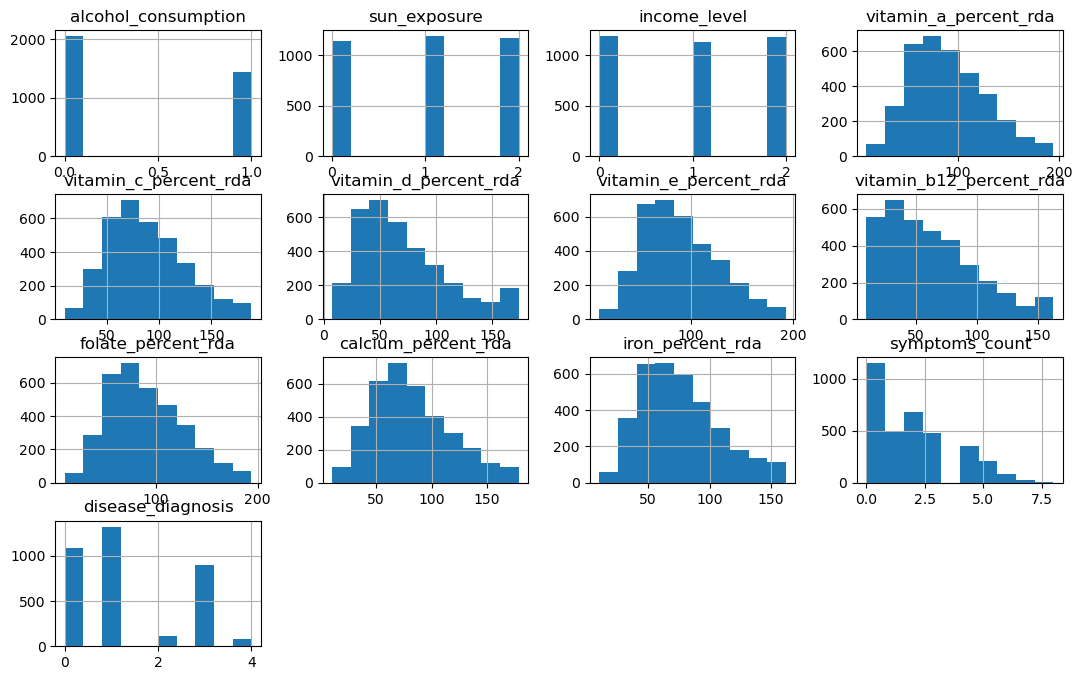

In [249]:
df.hist(figsize=(13,8))

In [250]:

PowerTransformer = PowerTransformer()

cols_2= ["vitamin_b12_percent_rda","vitamin_e_percent_rda","vitamin_d_percent_rda","vitamin_c_percent_rda","vitamin_a_percent_rda","folate_percent_rda","iron_percent_rda","calcium_percent_rda","symptoms_count"]
print(df[cols_2].skew())
df[cols_2] = PowerTransformer.fit_transform(df[cols_2])
print(df[cols_2].skew())

vitamin_b12_percent_rda    0.783431
vitamin_e_percent_rda      0.532000
vitamin_d_percent_rda      0.894572
vitamin_c_percent_rda      0.532031
vitamin_a_percent_rda      0.513189
folate_percent_rda         0.525638
iron_percent_rda           0.620544
calcium_percent_rda        0.585717
symptoms_count             0.713992
dtype: float64
vitamin_b12_percent_rda   -0.040339
vitamin_e_percent_rda     -0.015062
vitamin_d_percent_rda     -0.016963
vitamin_c_percent_rda     -0.015070
vitamin_a_percent_rda     -0.018813
folate_percent_rda        -0.016246
iron_percent_rda          -0.014931
calcium_percent_rda       -0.015596
symptoms_count            -0.023719
dtype: float64


array([[<Axes: title={'center': 'alcohol_consumption'}>,
        <Axes: title={'center': 'sun_exposure'}>,
        <Axes: title={'center': 'income_level'}>,
        <Axes: title={'center': 'vitamin_a_percent_rda'}>],
       [<Axes: title={'center': 'vitamin_c_percent_rda'}>,
        <Axes: title={'center': 'vitamin_d_percent_rda'}>,
        <Axes: title={'center': 'vitamin_e_percent_rda'}>,
        <Axes: title={'center': 'vitamin_b12_percent_rda'}>],
       [<Axes: title={'center': 'folate_percent_rda'}>,
        <Axes: title={'center': 'calcium_percent_rda'}>,
        <Axes: title={'center': 'iron_percent_rda'}>,
        <Axes: title={'center': 'symptoms_count'}>],
       [<Axes: title={'center': 'disease_diagnosis'}>, <Axes: >,
        <Axes: >, <Axes: >]], dtype=object)

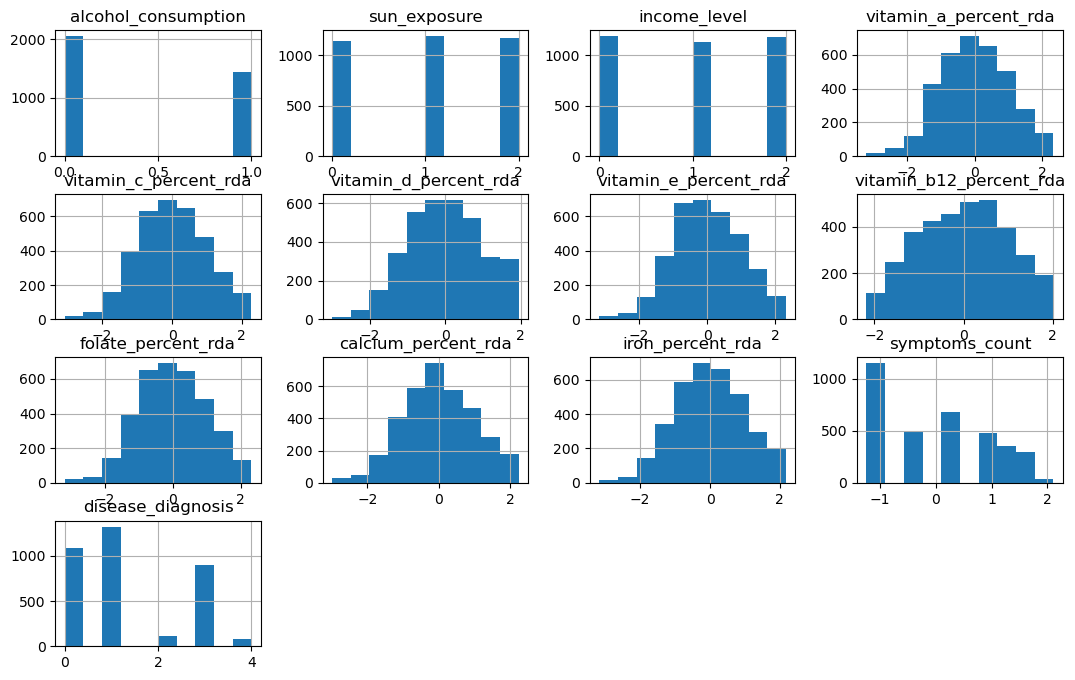

In [251]:
df.hist(figsize=(13,8))

In [252]:
scale = StandardScaler()
cols_3= ["vitamin_b12_percent_rda","vitamin_e_percent_rda","vitamin_d_percent_rda","vitamin_c_percent_rda","vitamin_a_percent_rda","folate_percent_rda","iron_percent_rda","calcium_percent_rda"]
df[cols_3]= pd.DataFrame(scale.fit_transform(df[cols_3]), columns=cols_3)


In [253]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   alcohol_consumption      3500 non-null   int64  
 1   sun_exposure             3500 non-null   int64  
 2   income_level             3500 non-null   int64  
 3   vitamin_a_percent_rda    3500 non-null   float64
 4   vitamin_c_percent_rda    3500 non-null   float64
 5   vitamin_d_percent_rda    3500 non-null   float64
 6   vitamin_e_percent_rda    3500 non-null   float64
 7   vitamin_b12_percent_rda  3500 non-null   float64
 8   folate_percent_rda       3500 non-null   float64
 9   calcium_percent_rda      3500 non-null   float64
 10  iron_percent_rda         3500 non-null   float64
 11  symptoms_count           3500 non-null   float64
 12  disease_diagnosis        3500 non-null   int64  
 13  diet_type_Omnivore       3500 non-null   bool   
 14  diet_type_Pescatarian   

In [254]:
X = df.drop(columns=["disease_diagnosis"])
y = df["disease_diagnosis"]
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

# decision tree

In [260]:
tree = DecisionTreeClassifier(criterion='entropy',random_state=100, max_depth=5, min_samples_leaf=5)
tree.fit(x_train,y_train)

y_pred = tree.predict(x_test)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred) * 100)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[218  15   0   0   0]
 [  0 251   0   0   0]
 [  0   0  16   0   0]
 [  0   0   0 173   0]
 [  4  10   1   0  12]]

Accuracy: 95.71428571428572

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96       233
           1       0.91      1.00      0.95       251
           2       0.94      1.00      0.97        16
           3       1.00      1.00      1.00       173
           4       1.00      0.44      0.62        27

    accuracy                           0.96       700
   macro avg       0.97      0.88      0.90       700
weighted avg       0.96      0.96      0.95       700



In [262]:
for n in [3,5,6]:
    tree = DecisionTreeClassifier(criterion='entropy',random_state=100, max_depth=n, min_samples_leaf=5)
    tree.fit(x_train,y_train)
    print(f"max_depth={n} -> Accuracy: {accuracy_score(y_test, tree.predict(x_test)) * 100:.2f}%")


max_depth=3 -> Accuracy: 86.43%
max_depth=5 -> Accuracy: 95.71%
max_depth=6 -> Accuracy: 98.00%


In [264]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scores=cross_val_score(tree,X,y,cv=cv,scoring='accuracy',n_jobs=-1)
print("✅Cross-validation accuracies✅:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("Std deviation:", np.std(cv_scores))

✅Cross-validation accuracies✅: [0.98142857 0.98714286 0.99       0.98857143 0.98285714]
Mean CV accuracy: 0.986
Std deviation: 0.0033073819722257663


In [271]:
from sklearn.model_selection import GridSearchCV
parm_tree = {
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [1, 5, 10]
}
grid = GridSearchCV(tree, parm_tree,cv=5)
grid.fit(x_train, y_train)
print("Best parameters:", grid.best_params_)
print("accuracy_score:", accuracy_score(y_test, grid.predict(x_test)) * 100)

Best parameters: {'max_depth': 7, 'min_samples_leaf': 1}
accuracy_score: 98.57142857142858


In [ ]:
# plt.figure(figsize=(20,8))
# plot_tree(tree, filled=True, feature_names=X.columns, class_names=y.classes_, rounded=True)

# XGB model

In [265]:
for n in [50,100,200]:
    xgb = XGBClassifier(random_state=42, n_estimators=n,learning_rate=0.1)
    xgb.fit(x_train, y_train)
    print(f"n_estimators={n} -> Accuracy: {accuracy_score(y_test, xgb.predict(x_test)) * 100:.2f}%")

n_estimators=50 -> Accuracy: 99.29%
n_estimators=100 -> Accuracy: 99.14%
n_estimators=200 -> Accuracy: 99.29%


In [266]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scores=cross_val_score(xgb,X,y,cv=cv,scoring='accuracy',n_jobs=-1)
print("✅Cross-validation accuracies✅:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("Std deviation:", np.std(cv_scores))

✅Cross-validation accuracies✅: [0.99428571 0.99857143 0.99714286 0.99571429 0.99571429]
Mean CV accuracy: 0.9962857142857142
Std deviation: 0.001456862718169354


In [272]:
from sklearn.model_selection import GridSearchCV
parm = {
    'n_estimators': [50, 100, 200,300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7,10]
}
grid = GridSearchCV(xgb, parm,cv=5)
grid.fit(x_train, y_train)
print("Best parameters:", grid.best_params_)
print("accuracy_score:", accuracy_score(y_test, grid.predict(x_test)) * 100)

Best parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}
accuracy_score: 99.42857142857143


In [273]:
for k in [3,5,7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    print(f"k={k} -> Accuracy: {accuracy_score(y_test, knn.predict(x_test)) * 100:.2f}%")

k=3 -> Accuracy: 82.43%
k=5 -> Accuracy: 81.86%
k=7 -> Accuracy: 82.14%


In [275]:
parm = {
    'n_neighbors': [3, 5, 7],
}
grid = GridSearchCV(knn, parm,cv=5)
grid.fit(x_train, y_train)
print("Best parameters:", grid.best_params_)
print("accuracy_score:", accuracy_score(y_test, grid.predict(x_test)) * 100)

Best parameters: {'n_neighbors': 5}
accuracy_score: 81.85714285714286
